# Benchmark Data Analysis

This notebook analyzes the verification benchmark data from `data.json` and calculates median values for:
- `duration_ms`: Total verification duration in milliseconds
- `user_time_secs`: User CPU time in seconds
- `system_time_secs`: System CPU time in seconds

## 1. Load and Parse JSON Data

In [7]:
import json
import os
import numpy as np

# Paths to the benchmark data files
benchmark_files = {
    "TPCC": "./tpcc_out/data.json",
    "Social": "./social_out/data.json",
    "RUBiS": "./rubis_out/data.json",
}

# Load JSON data for all benchmarks
topdatasets = {}
for name, path in benchmark_files.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing benchmark data file for {name}: {path}")
    with open(path, "r") as f:
        topdatasets[name] = json.load(f)

print("Loaded files:")
for name, path in benchmark_files.items():
    print(f"  {name}: {path}")

print("\nHigh-level verification stats:")
for name, data in topdatasets.items():
    total_verifications = len(data["c_edge_verifications"])
    passed_verifications = sum(1 for v in data["c_edge_verifications"] if v["result"] == "Pass")
    failed_verifications = sum(1 for v in data["c_edge_verifications"] if v["result"] == "Error")
    timeout_verifications = sum(1 for v in data["c_edge_verifications"] if v["result"] == "Timeout")
    print(f"{name}: total={total_verifications}, pass={passed_verifications}, error={failed_verifications}, timeout={timeout_verifications}")

# Build per-edge feature records for later analysis (Section 5)
feature_records = []
for benchmark_name, data in topdatasets.items():
    for v in data["c_edge_verifications"]:
        record = {
            "benchmark": benchmark_name,
            "duration_ms": float(v["duration_ms"]),
            "duration_secs": float(v["duration_ms"]) / 1000.0,
            "boogie_file_len": float(v.get("boogie_file_len", 0)),
            "real_procedure_len": float(v.get("real_procedure_len", 0)),
            "branch_count": float(v.get("branch_count", 0)),
            "has_loop": 1.0 if v.get("has_loop", False) else 0.0,
            "db_read_count": float(v.get("db_read_count", 0)),
            "db_write_count": float(v.get("db_write_count", 0)),
            "db_total_access": float(v.get("db_read_count", 0) + v.get("db_write_count", 0)),
            "result": v.get("result", "Unknown"),
        }
        feature_records.append(record)

print(f"\nTotal feature records: {len(feature_records)}")

# Keep these variables for existing histogram sections (Sections 2-4)
tpcc_data = topdatasets["TPCC"]
social_data = topdatasets["Social"]
rubis_data = topdatasets["RUBiS"]

Loaded files:
  TPCC: ./tpcc_out/data.json
  Social: ./social_out/data.json
  RUBiS: ./rubis_out/data.json

High-level verification stats:
TPCC: total=284, pass=232, error=10, timeout=42
Social: total=128, pass=10, error=118, timeout=0
RUBiS: total=91, pass=12, error=79, timeout=0

Total feature records: 503


## 2. Extract Duration

In [8]:
# Extract metrics from all verifications
tpcc_duration_ms_values = []
social_duration_ms_values = []
rubis_duration_ms_values = []

def extract_metrics(data, duration_ms_values):
    for verification in data['c_edge_verifications']:
        # Extract duration_ms (always present)
        duration_ms_values.append(verification['duration_ms'])

extract_metrics(tpcc_data, tpcc_duration_ms_values)
extract_metrics(social_data, social_duration_ms_values)
extract_metrics(rubis_data, rubis_duration_ms_values)
# delete the greatest value in tpcc_duration_ms_values to avoid outlier
# tpcc_duration_ms_values.remove(max(tpcc_duration_ms_values))

# divide all duration values by 1000 to convert to seconds
tpcc_duration_ms_values = [x / 1000.0 for x in tpcc_duration_ms_values]
social_duration_ms_values = [x / 1000.0 for x in social_duration_ms_values]
rubis_duration_ms_values = [x / 1000.0 for x in rubis_duration_ms_values]


# Group datasets and their titles for easier processing
datasets = {
    "TPCC": tpcc_duration_ms_values,
    "Social": social_duration_ms_values,
    "RUBiS": rubis_duration_ms_values,
}

## 3. Visualize Distribution

/tmp/ipykernel_3230330/3406773805.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


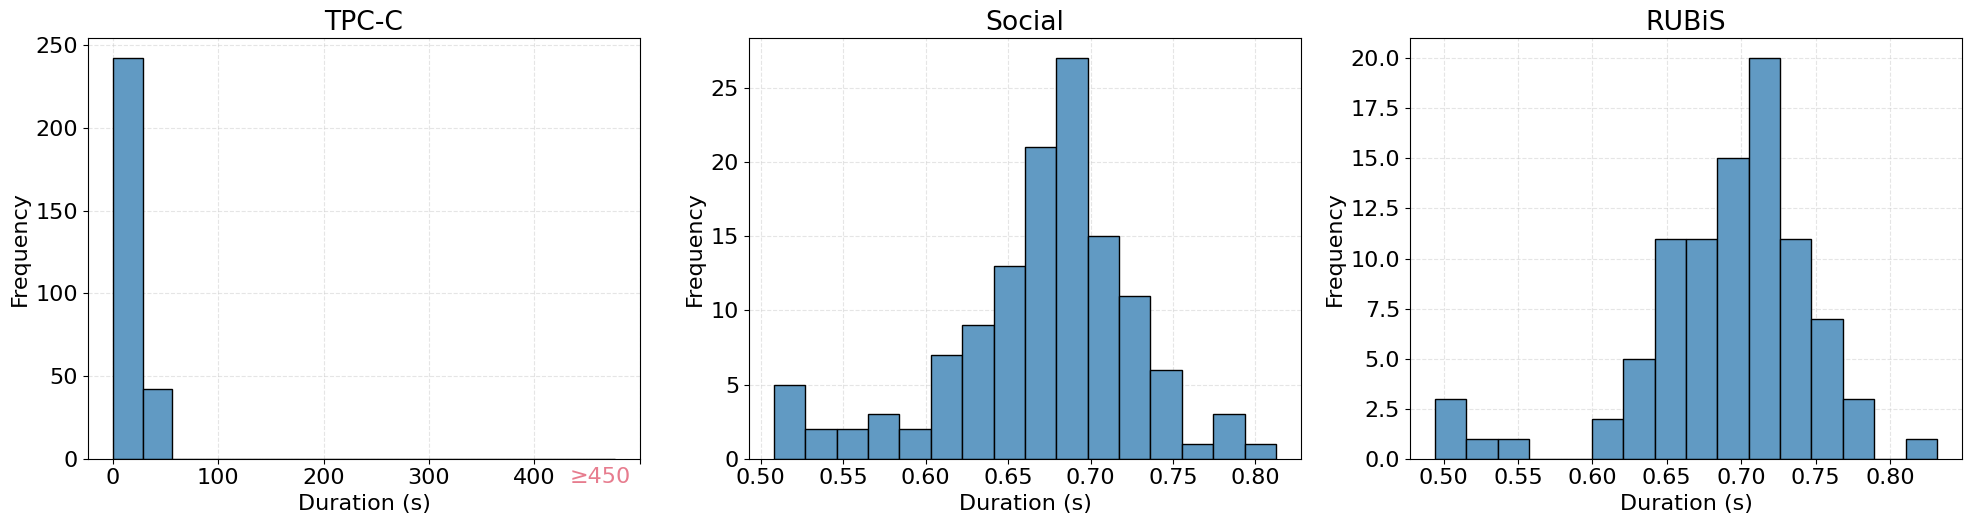

In [9]:
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np

# change to type1/truetype fonts: https://gecco-2025.sigevo.org/Paper-Submission-Instructions
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 16,
})

color_theme = {
    "myblue": (97/255, 154/255, 195/255),
    "myred": (231/255, 124/255, 142/255),
    "mygreen": (97/255, 172/255, 133/255),
    "myorange": (255/255, 153/255, 0/255),
    "edgecolor": "black",
    "gridcolor": "#cccccc",
    "linestyle": "--",
}

# --- Plotting Function ---
def create_histogram(ax, data, title, color_theme, use_log_scale=False, has_outlier=False, normal_range=None):
    """
    Creates a histogram, with an option to aggregate outliers into the last bin,
    which is colored differently and specially labeled.
    """
    # --- 1. Initial Setup and Validation ---
    if data is None or len(data) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
        ax.set_title(title)
        return
    if title is not None:
        ax.set_title(title)
    
    # --- 2. Data and Bin Configuration ---
    data_to_plot = np.copy(data)
    num_bins = 16 # Set the desired number of bins
    bins = num_bins
    xlabel = 'Duration (s)'

    if has_outlier:
        if normal_range is None or len(normal_range) != 2:
            raise ValueError("`normal_range` must be a tuple of (min, max) when has_outlier is True.")
        
        cutoff = normal_range[1]
        plot_end = (normal_range[1] - normal_range[0]) / (num_bins + 1) + normal_range[1]
        # Ensure exactly `num_bins` are created for the range, making the last one the outlier bin.
        # `num_bins + 1` is used to define the correct number of bin edges.
        bins = np.linspace(normal_range[0], plot_end, num_bins + 2)
        data_to_plot[data_to_plot > cutoff] = cutoff

    elif use_log_scale:
        min_val = np.min(data)
        max_val = np.max(data)
        if min_val <= 0: min_val = 1
        bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)
        ax.set_xscale('log')
        xlabel = 'Duration (s) [log scale]'

    # --- 3. Plotting ---
    _, _, patches = ax.hist(data_to_plot, bins=bins, color=color_theme["myblue"], edgecolor=color_theme["edgecolor"])
    ax.grid(True, which="both", ls=color_theme["linestyle"], color=color_theme["gridcolor"], alpha=0.5)
    ax.set_axisbelow(True)

    # --- 4. Final Labeling and Customization ---
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')

    if has_outlier:
        last_patch = patches[-1]

        outlier_face_color = color_theme["myred"]
        last_patch.set_facecolor(outlier_face_color)

        x_pos = last_patch.get_x() + last_patch.get_width() / 2
    
        ax.text(x_pos, -0.02, f'≥{int(cutoff)}', 
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', color=outlier_face_color)

        ticks = ax.get_xticks()
        # print(ticks)
        labels = ax.get_xticklabels()
        for i, tick in enumerate(ticks):
            if tick >= cutoff:
                labels = labels[:i+1]
                ticks = ticks[:i+1]
                labels[i].set_visible(False)
                break
        # ax.set_xticks(ticks)
        ax.set_xticklabels(labels)

# --- Main Execution ---
# 1. Create the combined figure with three subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

create_histogram(axes[0], datasets["TPCC"], "TPC-C", color_theme, has_outlier=True, normal_range=(0, 450.0)) # use_log_scale=True) #has_outlier=True, normal_range=(0, 450.0))
create_histogram(axes[1], datasets["Social"], "Social", color_theme)
create_histogram(axes[2], datasets["RUBiS"], "RUBiS", color_theme)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. Save figures without title

In [10]:
# Directory to save the figures
output_dir = "histogram_figures_out"
os.makedirs(output_dir, exist_ok=True) # Create the directory if it doesn't exist

print(f"Saving individual plots to '{output_dir}/' directory...")
for name, data in datasets.items():
    # Create a new, single figure for saving
    individual_fig, individual_ax = plt.subplots(figsize=(10, 6))
    if name == "TPCC":
        create_histogram(individual_ax, data, None, color_theme, has_outlier=True, normal_range=(0, 450.0)) # use_log_scale=True) #has_outlier=True, normal_range=(0, 450.0))
    else:
        create_histogram(individual_ax, data, None, color_theme, use_log_scale=False)
    
    # Define the output path and save the figure
    file_path = os.path.join(output_dir, f"{name.lower()}_histogram.pdf")
    individual_fig.savefig(file_path, bbox_inches='tight', format='pdf')
    
    # Close the figure to free up memory
    plt.close(individual_fig)


Saving individual plots to 'histogram_figures_out/' directory...


/tmp/ipykernel_3230330/3406773805.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


## 5. Feature Analysis for Verification Wall-Clock Time

/tmp/ipykernel_3230330/216816666.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


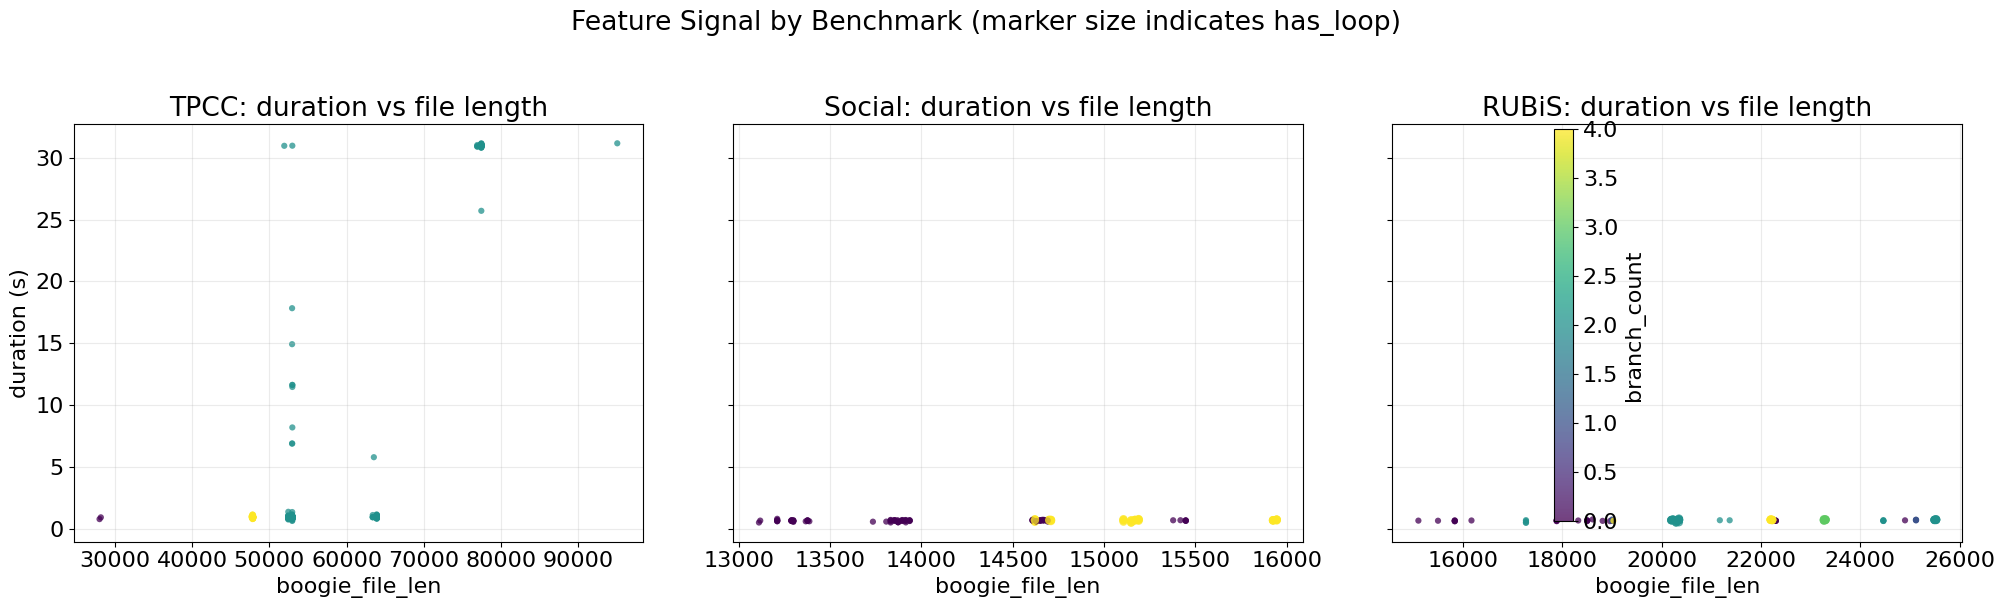

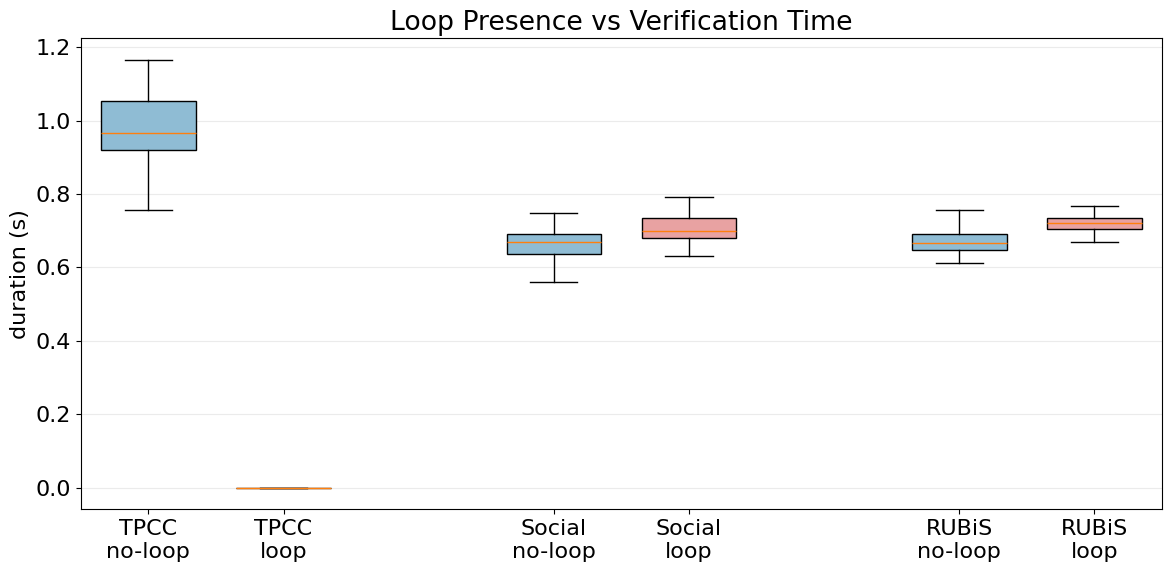

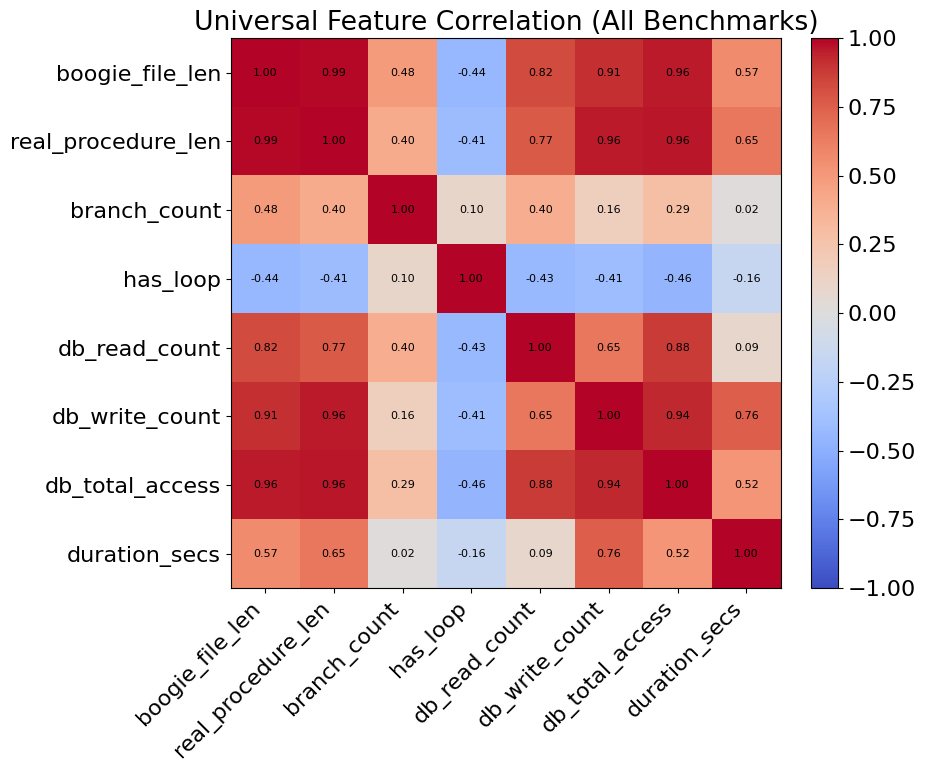

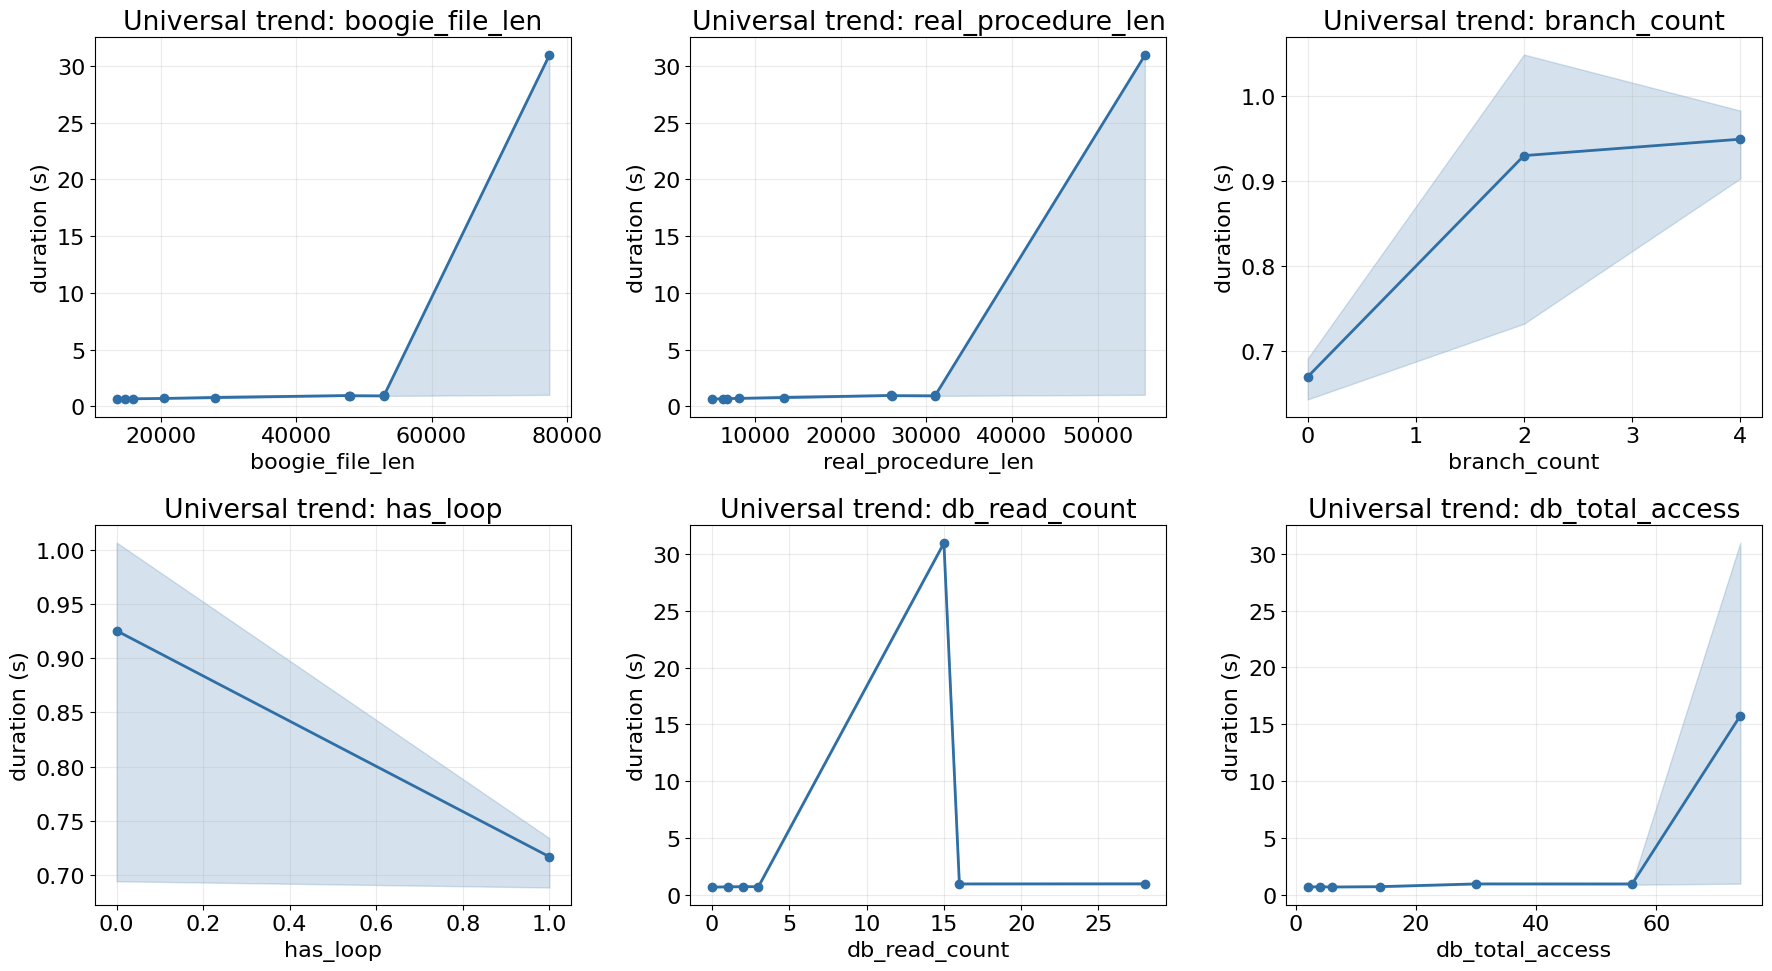

Feature analysis complete for each benchmark and combined (universal) dataset.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare benchmark-wise records
benchmarks = ["TPCC", "Social", "RUBiS"]
records_by_benchmark = {
    name: [r for r in feature_records if r["benchmark"] == name]
    for name in benchmarks
}

# ----------------------------
# Figure 5.1: Per-benchmark feature scatter (duration vs file length)
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, bench in enumerate(benchmarks):
    recs = records_by_benchmark[bench]
    x = np.array([r["boogie_file_len"] for r in recs], dtype=float)
    y = np.array([r["duration_secs"] for r in recs], dtype=float)
    c = np.array([r["branch_count"] for r in recs], dtype=float)
    s = np.array([36 if r["has_loop"] > 0.5 else 20 for r in recs], dtype=float)

    sc = axes[i].scatter(x, y, c=c, s=s, cmap="viridis", alpha=0.75, edgecolor="none")
    axes[i].set_title(f"{bench}: duration vs file length")
    axes[i].set_xlabel("boogie_file_len")
    if i == 0:
        axes[i].set_ylabel("duration (s)")
    axes[i].grid(alpha=0.25)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("branch_count")
fig.suptitle("Feature Signal by Benchmark (marker size indicates has_loop)", y=1.02)
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 5.2: Loop vs non-loop wall-clock distribution by benchmark
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

positions = []
box_data = []
labels = []
base = 1

for bench in benchmarks:
    recs = records_by_benchmark[bench]
    no_loop = [r["duration_secs"] for r in recs if r["has_loop"] < 0.5]
    has_loop = [r["duration_secs"] for r in recs if r["has_loop"] >= 0.5]

    box_data.extend([no_loop if no_loop else [0.0], has_loop if has_loop else [0.0]])
    positions.extend([base, base + 1])
    labels.extend([f"{bench}\nno-loop", f"{bench}\nloop"])
    base += 3

bp = ax.boxplot(box_data, positions=positions, widths=0.7, patch_artist=True, showfliers=False)
for j, patch in enumerate(bp["boxes"]):
    patch.set_facecolor("#8fbcd4" if j % 2 == 0 else "#e8a2a2")

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel("duration (s)")
ax.set_title("Loop Presence vs Verification Time")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 5.3: Universal feature correlation heatmap (all benchmarks combined)
# ----------------------------
feature_names = [
    "boogie_file_len",
    "real_procedure_len",
    "branch_count",
    "has_loop",
    "db_read_count",
    "db_write_count",
    "db_total_access",
    "duration_secs",
]

X = np.array([[r[f] for f in feature_names] for r in feature_records], dtype=float)
corr = np.corrcoef(X, rowvar=False)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha="right")
ax.set_yticks(np.arange(len(feature_names)))
ax.set_yticklabels(feature_names)
ax.set_title("Universal Feature Correlation (All Benchmarks)")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 5.4: Universal trend curves (binned median duration)
# ----------------------------
def binned_trend(records, feature_key, bins=10):
    x = np.array([r[feature_key] for r in records], dtype=float)
    y = np.array([r["duration_secs"] for r in records], dtype=float)

    if np.allclose(x.min(), x.max()):
        return np.array([x.min()]), np.array([np.median(y)]), np.array([np.median(y)]), np.array([np.median(y)])

    edges = np.quantile(x, np.linspace(0, 1, bins + 1))
    edges[0] = x.min() - 1e-9
    edges[-1] = x.max() + 1e-9

    centers, y50, y25, y75 = [], [], [], []
    for i in range(bins):
        mask = (x >= edges[i]) & (x < edges[i + 1])
        if not np.any(mask):
            continue
        xv = x[mask]
        yv = y[mask]
        centers.append(float(np.median(xv)))
        y50.append(float(np.median(yv)))
        y25.append(float(np.quantile(yv, 0.25)))
        y75.append(float(np.quantile(yv, 0.75)))

    return np.array(centers), np.array(y50), np.array(y25), np.array(y75)

trend_features = [
    "boogie_file_len",
    "real_procedure_len",
    "branch_count",
    "has_loop",
    "db_read_count",
    "db_total_access",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(trend_features):
    cx, med, q25, q75 = binned_trend(feature_records, feat, bins=10)
    axes[i].plot(cx, med, marker="o", linewidth=2, color="#2f6fa5")
    axes[i].fill_between(cx, q25, q75, alpha=0.2, color="#2f6fa5")
    axes[i].set_title(f"Universal trend: {feat}")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("duration (s)")
    axes[i].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Feature analysis complete for each benchmark and combined (universal) dataset.")